# Day 1 — From Machine Learning to Deep Learning

## Note 1.2 — The Learning Mechanism, Traced By Hand

## Learning Goal & Outcome

**Goal.** Trace every step from input to updated parameter, computing each number yourself.

**Outcome.** You can answer the day's competency question — *what happens between giving data to a neural network and the model improving?* — and defend every step of your answer with arithmetic you performed. When `loss.backward()` appears in Note 1.3, you will know exactly what it did, because you will have done it first.

## Objectives

By the end of this note you will be able to:

- explain neuron, weights, bias, activation, layer and parameter, precisely;
- count the parameters in a network from its shape alone;
- compute a forward pass by hand and verify it in code;
- explain why a non-linearity is structurally necessary, not a stylistic choice;
- explain loss as a differentiable signal of wrongness;
- interpret a gradient as a local slope, and say what its sign and magnitude mean;
- read a computational graph and explain what it stores;
- perform backpropagation by hand as credit assignment through that graph;
- execute one parameter update and predict its effect on the loss;
- explain what the learning rate controls and what happens at both extremes.

## Dataset Used

**None.** This note uses eight hand-chosen numbers — four training examples with two features each — held in plain NumPy arrays defined in the notebook.

That is deliberate. Every value in this note is small enough to print in full, check against a calculator, and hold in your head at once. Nothing is hidden behind a library call. The whole point is that by the end you will have *been* the optimiser.

## Table of Contents

1. [Anatomy of a neuron and a network](#s1)
2. [Counting parameters](#s2)
3. [Forward propagation, computed by hand](#s3)
4. [Why non-linearity is not optional](#s4)
5. [Loss: a differentiable signal of wrongness](#s5)
6. [Gradients as local slope](#s6)
7. [The computational graph](#s7)
8. [Backpropagation as credit assignment](#s8)
9. [One parameter update, by hand](#s9)
10. [Looping it: watching loss fall](#s10)
11. [The learning rate](#s11)
12. [The bridge: PyTorch reproduces your arithmetic exactly](#s12)
13. [Conclusion](#s13)

## Setup

NumPy only for the first eleven sections. PyTorch appears once, in Section 12, purely as a referee.

In [1]:
# numpy>=2.0  matplotlib>=3.8  torch>=2.4
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
SEED = 42

print("numpy", np.__version__)
try:
    import torch
    dev = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"torch {torch.__version__} -> device: {dev}")
except ImportError:
    print("torch not installed — install it before Section 12:  pip install torch")

numpy 2.3.5
torch 2.14.0 -> device: mps


## 1. Anatomy of a neuron and a network

Strip away the vocabulary and a neuron does two things in sequence.

First it computes a **weighted sum** of its inputs and adds a **bias**:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

You have seen this before. It is a linear model. If you stopped here, a neuron would be exactly the logistic regression that failed in Note 1.1.

Second, it passes that sum through an **activation function**:

$$a = f(z)$$

That second step is the entire difference, and Section 4 shows why removing it destroys the network.

The vocabulary, precisely:

| Term | What it actually is |
|---|---|
| **Weight** $w$ | A learned number scaling one input. How much this input matters to this neuron. |
| **Bias** $b$ | A learned number added regardless of input. Shifts the threshold at which the neuron activates. |
| **Pre-activation** $z$ | The weighted sum before the activation. Sometimes called the logit at the output layer. |
| **Activation** $a$ | The neuron's output after $f$. This is what the next layer receives. |
| **Layer** | A group of neurons applied to the same input, computed together as one matrix multiply. |
| **Parameter** | Any number the model *learns* — every weight and every bias. |
| **Hyperparameter** | Any number *you* choose — learning rate, layer widths, number of epochs. |

The last distinction matters more than it looks. Parameters are found by gradient descent. Hyperparameters are found by you, by experiment, and getting them wrong is the most common reason a training run fails. That is Day 3.

<div align="center">

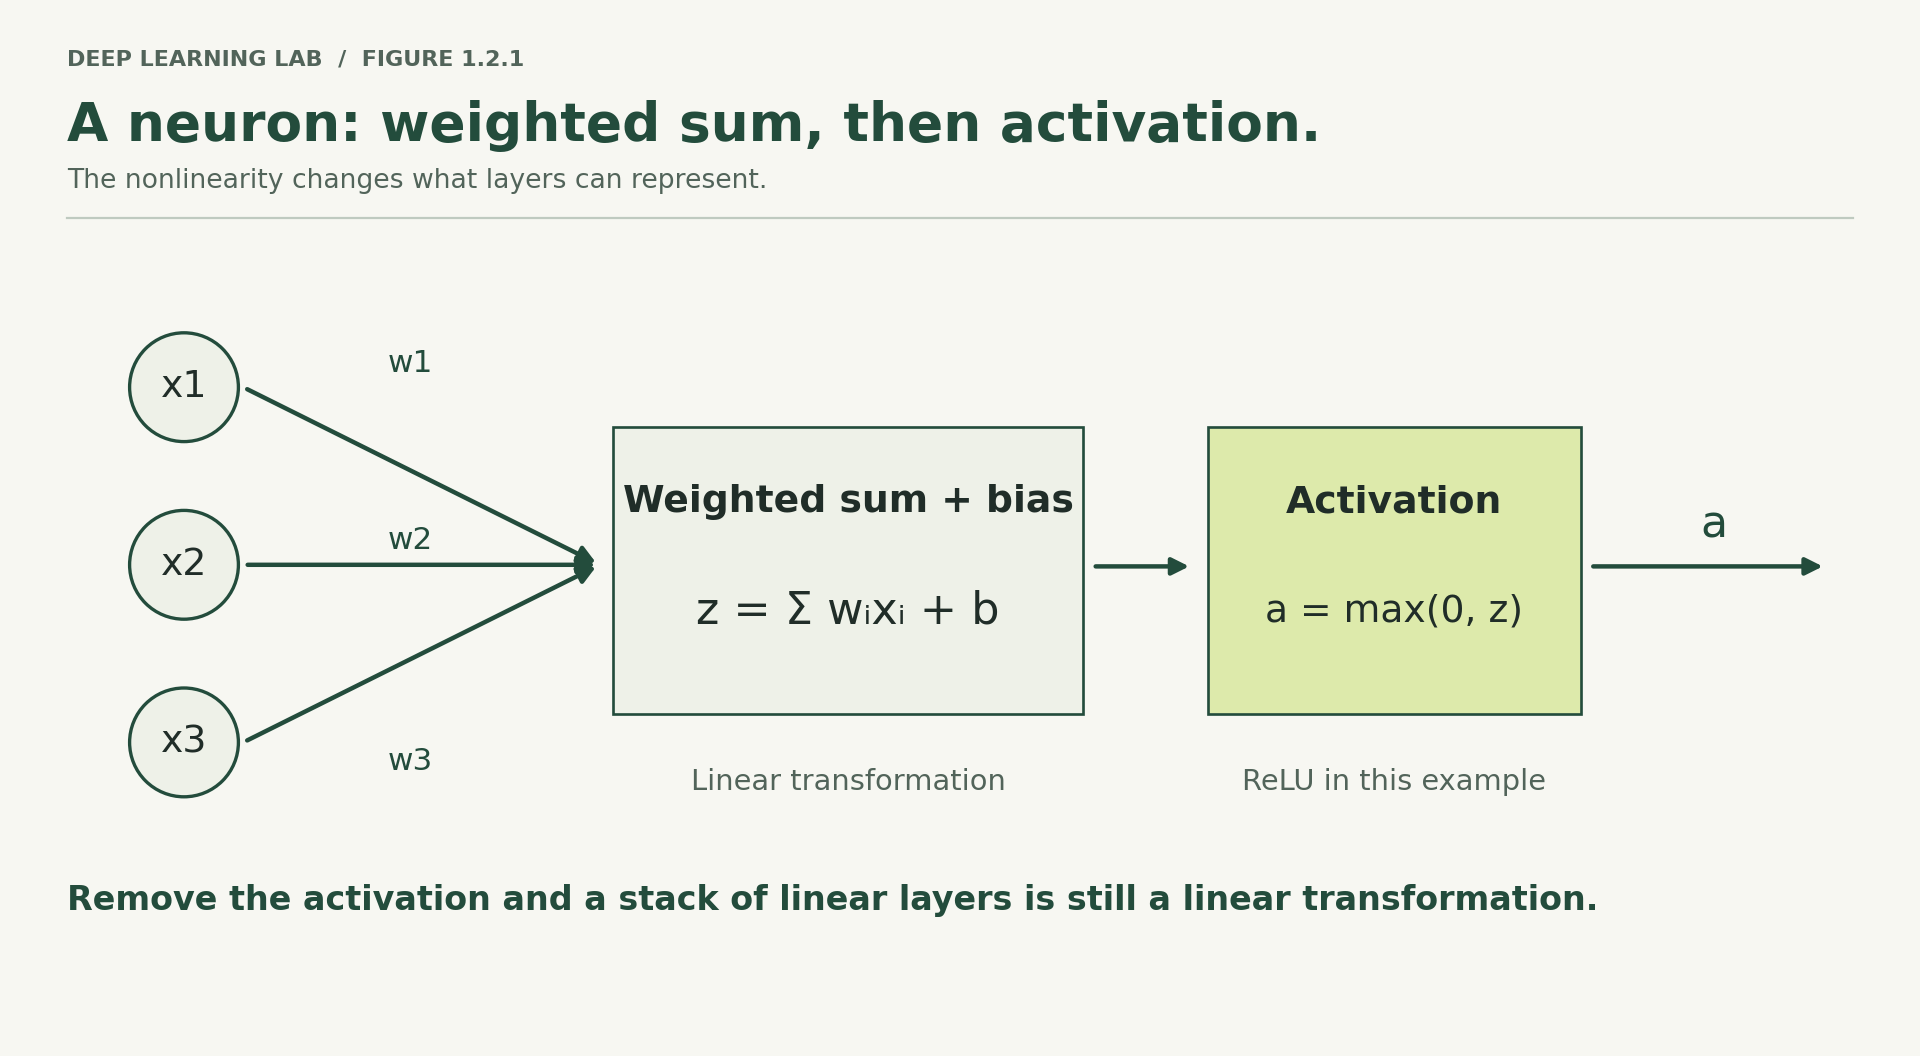

<p><b>Figure 1.2.1.</b> Each input is multiplied by its weight, a bias is added, and an activation acts on the result. ReLU is the example shown.</p>

</div>

<div align="center">

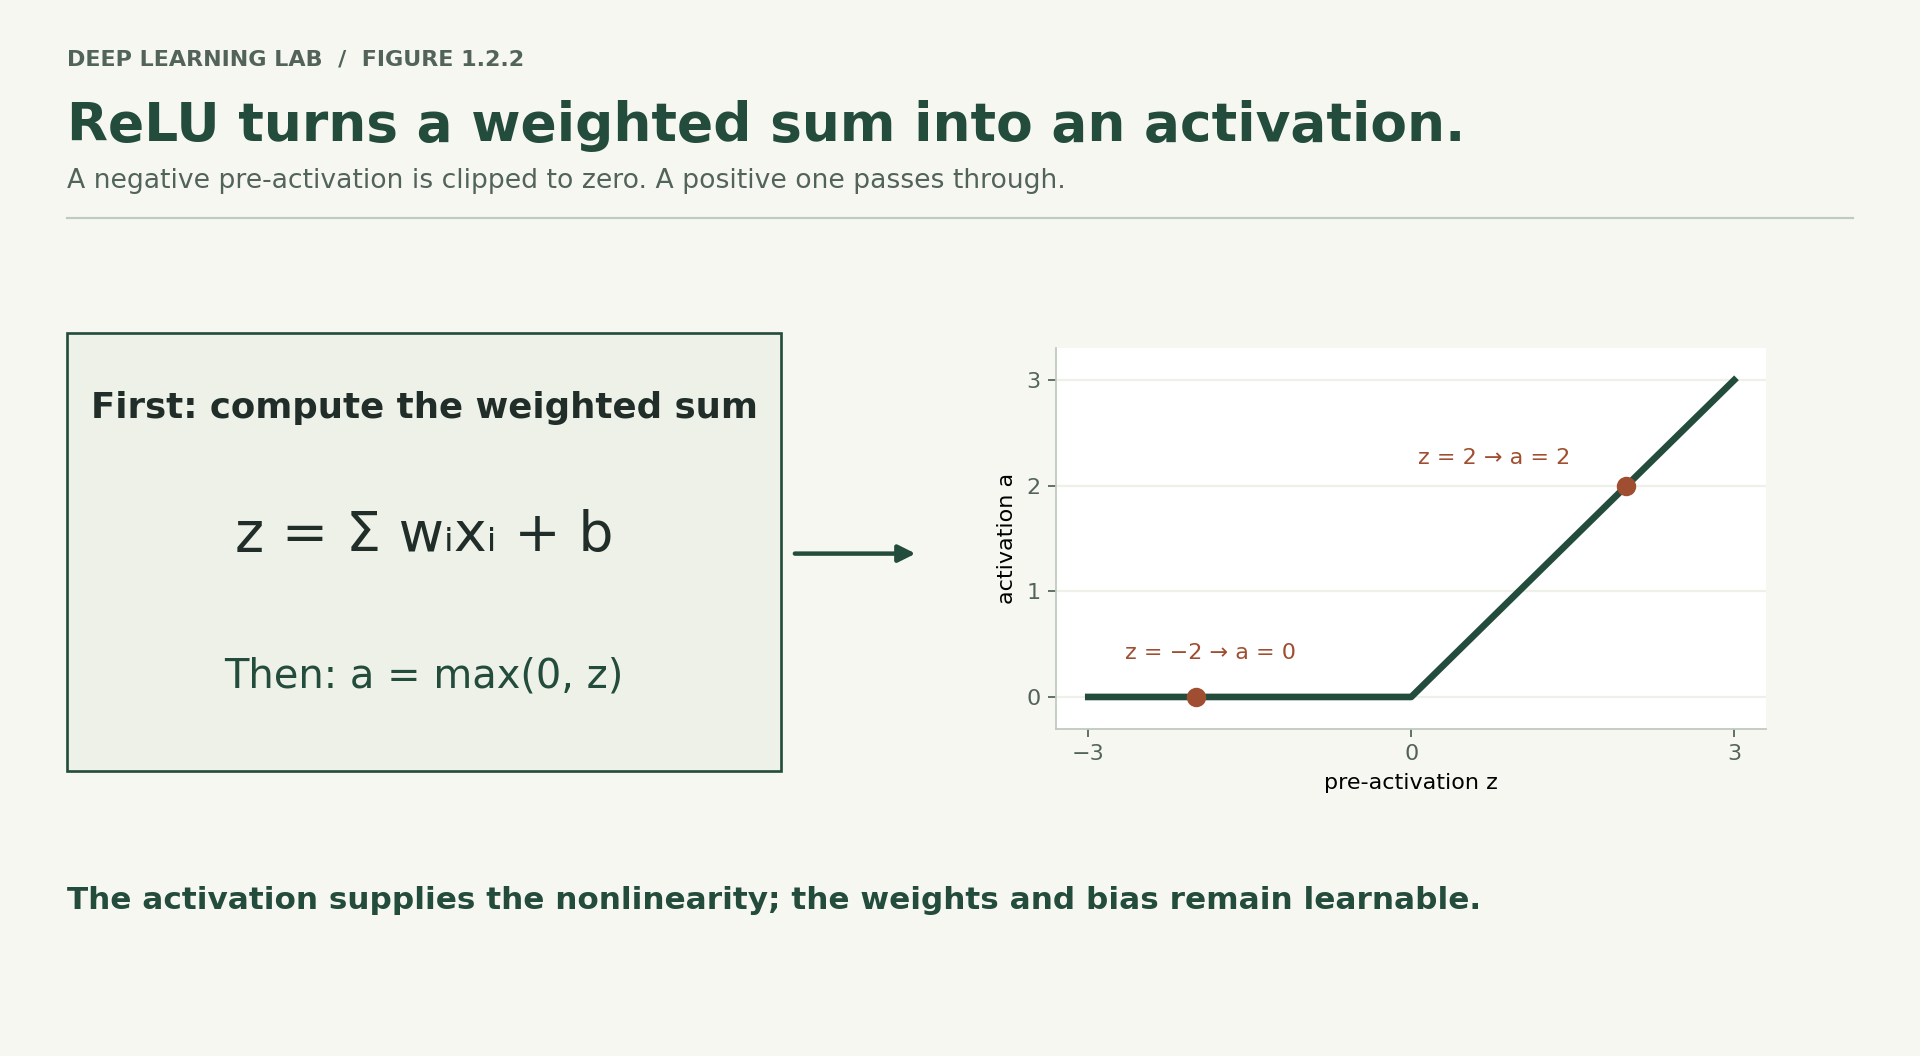

<p><b>Figure 1.2.2.</b> The same neuron computation viewed through its ReLU response. Negative z gives zero; positive z gives a=z.</p>

</div>

**Questions.**

1. What would a neuron with no bias be unable to represent?
2. If two neurons in the same layer receive identical inputs, what makes their outputs differ?
3. Why is the learning rate a hyperparameter rather than a parameter? What would go wrong if we learned it by gradient descent the same way we learn weights?

## 2. Counting parameters

Here is the network we will use for the rest of this note. It is deliberately the smallest thing that is still genuinely a neural network.

<div align="center">

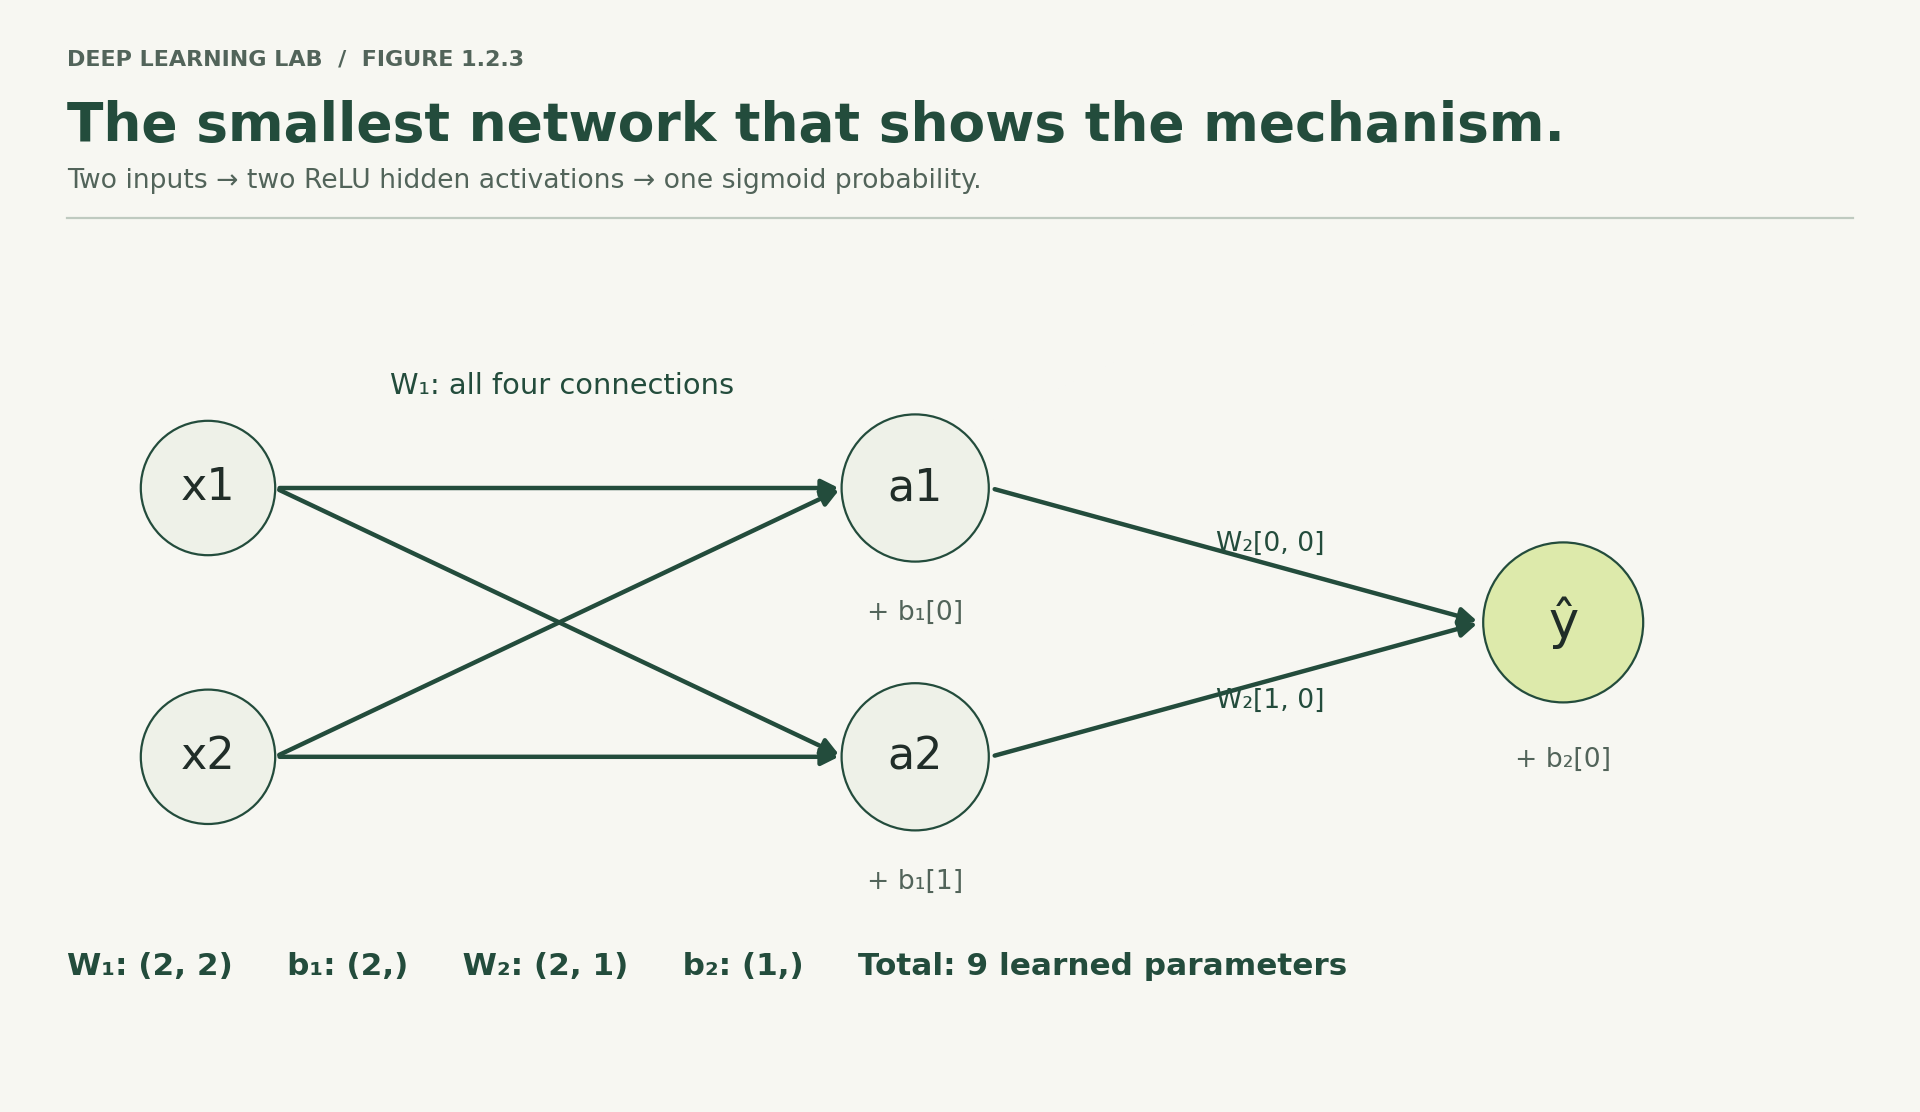

<p><b>Figure 1.2.3.</b> The lesson’s two-hidden-unit network. Weight and bias indexing matches the NumPy arrays used by its forward pass.</p>

</div>

Two inputs, two hidden neurons, one output. Let us count what it has to learn.

Every layer of shape (inputs → outputs) contributes `inputs × outputs` weights plus `outputs` biases.

- Input to hidden: $2 \times 2 = 4$ weights, plus 2 biases = **6**
- Hidden to output: $2 \times 1 = 2$ weights, plus 1 bias = **3**
- **Total: 9 parameters.**

Nine numbers. That is the entire model. Everything in this note is about how those nine numbers change.

For contrast, the spiral network in Note 1.1 had 4,417, and a modern language model has somewhere between a billion and a trillion. The arithmetic below is identical in all three cases. Only the count changes.

In [2]:
((2*64) + 64) + ((64*64)+64) + ((64*1)+1)

4417

In [3]:
def count_params(layer_sizes):
    """Parameter count for a fully connected network of the given layer widths."""
    total = 0
    print(f"{'layer':<18}{'weights':>10}{'biases':>9}{'subtotal':>11}")
    print("-" * 48)
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        w, b = n_in * n_out, n_out
        total += w + b
        print(f"{f'{n_in} -> {n_out}':<18}{w:>10,}{b:>9,}{w + b:>11,}")
    print("-" * 48)
    print(f"{'TOTAL':<18}{'':>10}{'':>9}{total:>11,}")
    return total

In [4]:
print("Our network:")
count_params([2, 2, 1])

Our network:
layer                weights   biases   subtotal
------------------------------------------------
2 -> 2                     4        2          6
2 -> 1                     2        1          3
------------------------------------------------
TOTAL                                          9


9

In [5]:
print("\nThe spiral network from Note 1.1:")
count_params([2, 64, 32,16,8, 1])


The spiral network from Note 1.1:
layer                weights   biases   subtotal
------------------------------------------------
2 -> 64                  128       64        192
64 -> 32               2,048       32      2,080
32 -> 16                 512       16        528
16 -> 8                  128        8        136
8 -> 1                     8        1          9
------------------------------------------------
TOTAL                                      2,945


2945

In [6]:
count_params([784, 512, 256, 10])

layer                weights   biases   subtotal
------------------------------------------------
784 -> 512           401,408      512    401,920
512 -> 256           131,072      256    131,328
256 -> 10              2,560       10      2,570
------------------------------------------------
TOTAL                                    535,818


535818

**Question.** A network with layers `[784, 512, 256, 10]` classifies 28×28 images. Predict the parameter count before running `count_params([784, 512, 256, 10])`. Which single layer dominates, and why?

## 3. Forward propagation, computed by hand

Now we fix actual numbers. Four training examples, two features each, binary labels. The initial weights below are not random — they are chosen so the arithmetic is easy to follow.

In [7]:
# Four examples, two features each
X = np.array([[ 0.5, -1.0],
              [ 1.5,  0.5],
              [-1.0,  1.0],
              [ 0.0, -0.5]])

# Their true labels
y = np.array([[1.0],
              [1.0],
              [0.0],
              [0.0]])

In [8]:
X

array([[ 0.5, -1. ],
       [ 1.5,  0.5],
       [-1. ,  1. ],
       [ 0. , -0.5]])

In [9]:
y

array([[1.],
       [1.],
       [0.],
       [0.]])

In [10]:
# Layer 1: 2 inputs -> 2 hidden neurons
W1 = np.array([[0.50, -0.20],     # column 0 -> hidden neuron 1, column 1 -> hidden neuron 2
               [0.30,  0.80]])

b1 = np.array([[0.10, -0.15]])

In [11]:
[['w11', 'w12'],
 ['w21', 'w22']]

[['w11', 'w12'], ['w21', 'w22']]

In [12]:
# Layer 2: 2 hidden -> 1 output
W2 = np.array([[ 0.70],
               [-0.40]])
b2 = np.array([[0.20]])

In [13]:
print("X shape", X.shape, "| W1 shape", W1.shape, "| W2 shape", W2.shape)
print("total parameters:", W1.size + b1.size + W2.size + b2.size)

X shape (4, 2) | W1 shape (2, 2) | W2 shape (2, 1)
total parameters: 9


**Do this by hand before running the next cell.** Take the first example, $x = [0.5, -1.0]$, and compute the pre-activation of hidden neuron 1:

$$z_1 = 0.5 \times 0.50 + (-1.0) \times 0.30 + 0.10 = 0.25 - 0.30 + 0.10 = 0.05$$

Now do hidden neuron 2 yourself. Its weights are the second column of `W1`: $-0.20$ and $0.80$, with bias $-0.10$.

You should get $z_2 = 0.5 \times (-0.20) + (-1.0) \times 0.80 + (-0.15) = -0.10 - 0.80 - 0.15 = -1.05$.

Next, apply **ReLU**, which is simply $f(z) = \max(0, z)$ — pass positives through unchanged, clamp negatives to zero. So $a_1 = 0.05$ and $a_2 = 0.00$.

Notice what just happened to hidden neuron 2. Its pre-activation was negative, so ReLU clamped it to exactly zero. For this example it contributes nothing at all to the prediction — and, as you will see in Section 8, no gradient will flow back to it through this example either. That is not a malfunction. It is ReLU behaving as designed, and it is why deep networks are sparser than they look.

In [14]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [15]:
# ---- forward pass, all four examples at once ----
Z1 = X @ W1 + b1        # (4,2) @ (2,2) + (1,2) -> (4,2)   broadcasting adds the bias to every row
A1 = relu(Z1)           # (4,2)

In [16]:
Z1

array([[ 0.05, -1.05],
       [ 1.  , -0.05],
       [-0.1 ,  0.85],
       [-0.05, -0.55]])

In [17]:
A1

array([[0.05, 0.  ],
       [1.  , 0.  ],
       [0.  , 0.85],
       [0.  , 0.  ]])

In [18]:
Z2 = A1 @ W2 + b2       # (4,2) @ (2,1) + (1,1) -> (4,1)
A2 = sigmoid(Z2)        # (4,1)  final probabilities
A2

array([[0.5585],
       [0.7109],
       [0.4651],
       [0.5498]])

In [19]:
print("Z1 (pre-activation, hidden layer)\n", Z1)
print("\nA1 (after ReLU) — note the zeros\n", A1)
print("\nZ2 (pre-activation, output)\n", Z2)
print("\nA2 (predicted probability of class 1)\n", A2)
print("\ny  (truth)\n", y)

Z1 (pre-activation, hidden layer)
 [[ 0.05 -1.05]
 [ 1.   -0.05]
 [-0.1   0.85]
 [-0.05 -0.55]]

A1 (after ReLU) — note the zeros
 [[0.05 0.  ]
 [1.   0.  ]
 [0.   0.85]
 [0.   0.  ]]

Z2 (pre-activation, output)
 [[ 0.235]
 [ 0.9  ]
 [-0.14 ]
 [ 0.2  ]]

A2 (predicted probability of class 1)
 [[0.5585]
 [0.7109]
 [0.4651]
 [0.5498]]

y  (truth)
 [[1.]
 [1.]
 [0.]
 [0.]]


Check the first row against your hand calculation. `Z1[0]` should read `[0.05, -1.05]`, and `A1[0]` should read `[0.05, 0.00]`.

The final column is the model's opinion. Example 1 should be class 1 and the model says about 0.56 — right side of the fence, but barely. Example 4 should be class 0 and the model puts it above 0.5, which is simply wrong. Three of four correct, by something close to luck. This network knows nothing yet, which is precisely what we are about to fix.

Two details worth naming, because both will bite you later:

**Why sigmoid at the output but ReLU in the hidden layer?** Different jobs. The output must be a probability, so it needs squashing into $(0, 1)$. Hidden units have no such requirement — they just need to be non-linear, and ReLU is faster and better behaved during training.

**Why do all four examples go through at once?** Because `X @ W1` is one matrix multiplication instead of four separate ones. That is the entire reason GPUs matter to deep learning: this shape of computation parallelises almost perfectly. Note 1.3 makes this concrete.

<div align="center">

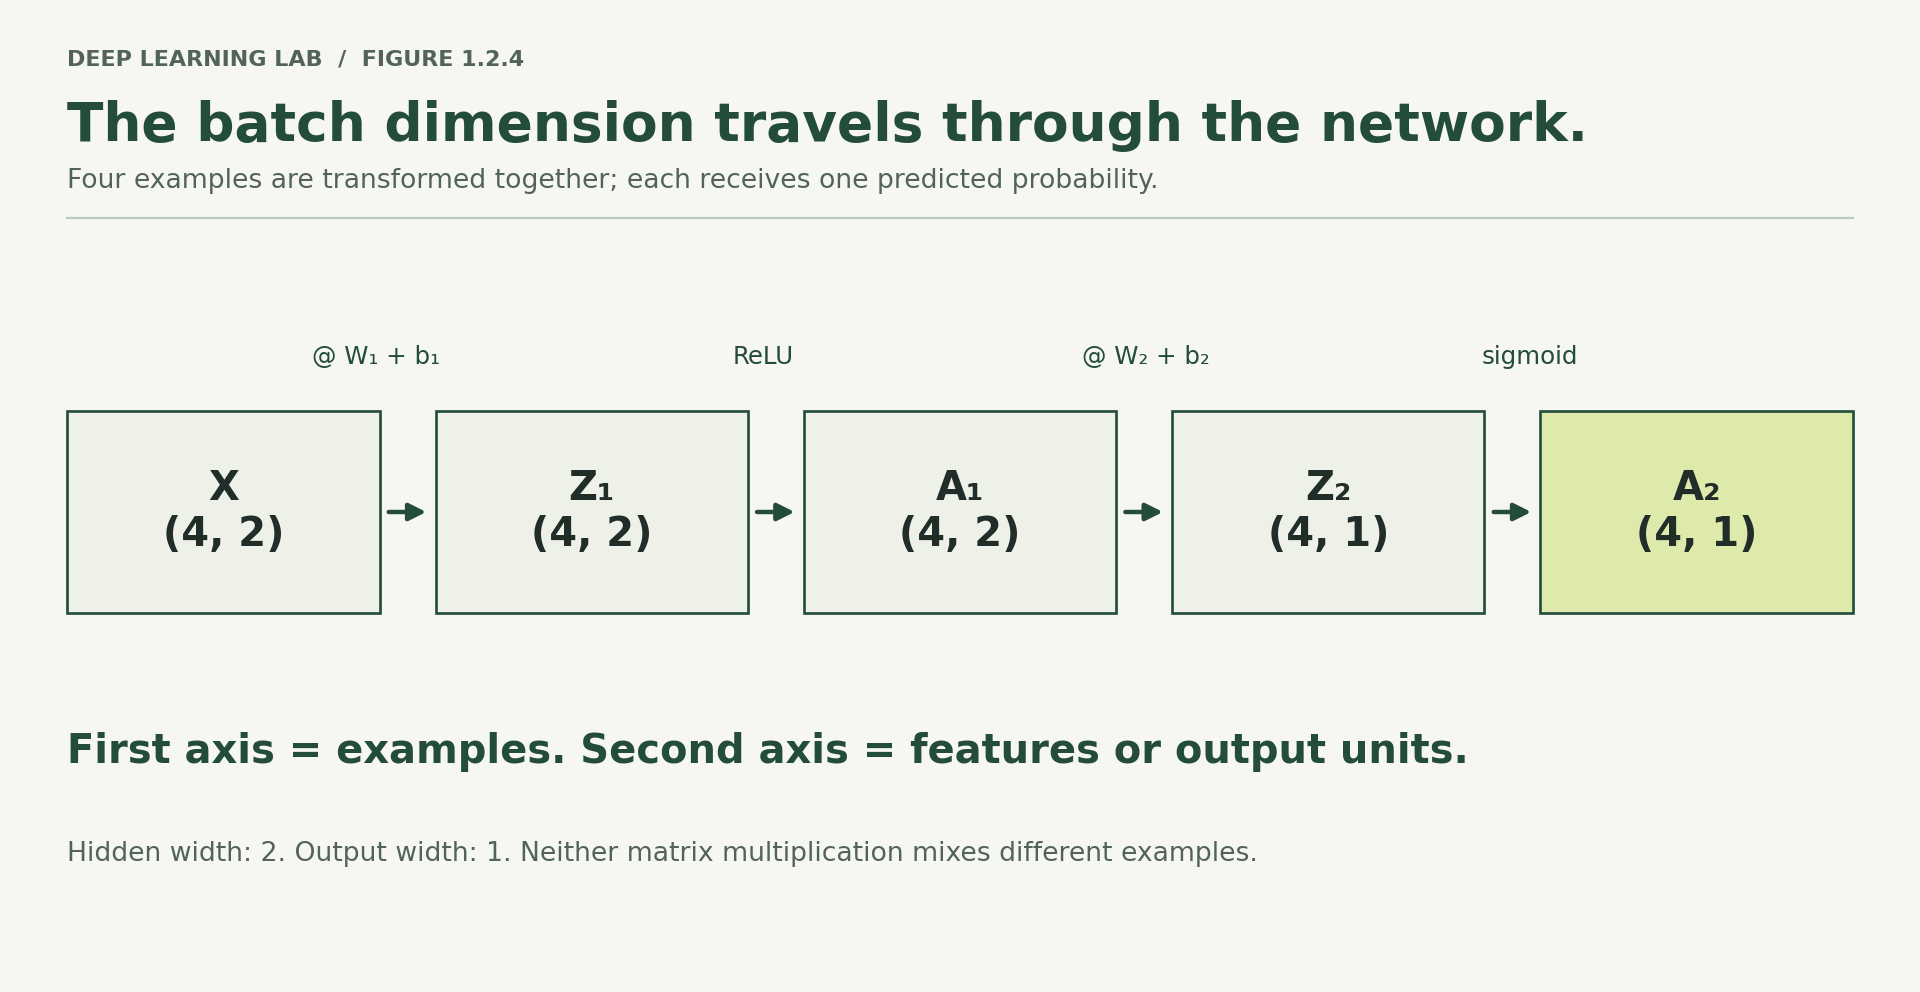

<p><b>Figure 1.2.4.</b> A four-row batch keeps its first dimension at each stage: input, hidden pre-activation, ReLU activation, output logit and probability.</p>

</div>

**Questions.**

1. If you added a fifth training example, which shapes in the diagram change and which stay fixed?
2. Hidden neuron 2 output zero for example 1. For which other examples does it also output zero? Check `A1`.
3. What would `A2` look like if every weight were zero?

## 4. Why non-linearity is not optional

It is tempting to view the activation function as a detail — a tweak that helps a bit. It is not. Without it, depth is worthless, and the reason is a two-line piece of algebra.

Suppose we drop ReLU, so each layer is purely linear. Then:

$$\text{output} = (X W_1 + b_1) W_2 + b_2 = X (W_1 W_2) + (b_1 W_2 + b_2)$$

Look at the right-hand side. $W_1 W_2$ is just some matrix. $b_1 W_2 + b_2$ is just some vector. So the whole two-layer network collapses into $XW' + b'$ — a **single linear layer**. Stack fifty such layers and it still collapses to one.

That is the punchline: a network with no activation function, however deep, is exactly as expressive as logistic regression. It would fail on the spirals for precisely the reason Note 1.1 failed. Let us verify it numerically rather than take it on faith.

In [20]:
# Path A: two linear layers, no activation
linear_two_layer = (X @ W1 + b1) @ W2 + b2

In [21]:
# Path B: collapse them algebraically into ONE layer, then apply it
W_collapsed = W1 @ W2            # (2,2) @ (2,1) -> (2,1)
b_collapsed = b1 @ W2 + b2       # (1,2) @ (2,1) + (1,1) -> (1,1)
linear_one_layer = X @ W_collapsed + b_collapsed

print("two linear layers:\n", linear_two_layer)
print("\none equivalent layer:\n", linear_one_layer)
print("\nidentical?", np.allclose(linear_two_layer, linear_one_layer))
print("\nWith ReLU in between (cannot be collapsed):\n", relu(X @ W1 + b1) @ W2 + b2)

two linear layers:
 [[ 0.655]
 [ 0.92 ]
 [-0.21 ]
 [ 0.385]]

one equivalent layer:
 [[ 0.655]
 [ 0.92 ]
 [-0.21 ]
 [ 0.385]]

identical? True

With ReLU in between (cannot be collapsed):
 [[ 0.235]
 [ 0.9  ]
 [-0.14 ]
 [ 0.2  ]]


Identical to floating-point precision. The depth bought nothing.

The third output is different — and it is different *because* ReLU zeroed some values, which is an operation no single matrix can reproduce. That small act of clipping is what makes the composition irreducible, and therefore what makes depth meaningful.

The blueprint for this course warns against turning it into a taxonomy of activation functions, so we will not tour them. What you need in 2026 is short: **ReLU and its close relatives (GELU, SiLU) for hidden layers; sigmoid for a binary output; softmax for multi-class output.** Modern Transformers overwhelmingly use GELU or SiLU internally, which are smoothed versions of the same idea. You will meet them again on Day 6.

**Questions.**

1. Explain in one sentence to a colleague why stacking linear layers is pointless.
2. ReLU is not differentiable at exactly zero. Does that break gradient descent? What do you think frameworks do about it?
3. If ReLU outputs zero for a neuron on *every* training example, what can that neuron ever learn? (This has a name — "dying ReLU" — and it returns on Day 3.)

## 5. Loss: a differentiable signal of wrongness

The model has produced its predictions. Some are correct; some are wrong.

But for the model to improve, we need a way to **measure how wrong it is**.

More precisely, we need that wrongness expressed as **a single number that changes smoothly as the model’s parameters change.**

Both parts of that requirement matter.

**A single number**, because gradient descent needs one quantity to minimise. It needs a clear answer to the question: *“How good or bad is the model right now?”*

**Smoothly**, because gradient descent improves the model by making tiny adjustments to its parameters. We need to know how a tiny change in a weight affects that number. If the number changes smoothly, we can calculate a **slope** and use it to determine which direction to move.

This is why we do not optimise **accuracy** directly.

Imagine changing a weight by 0.0001. The model's accuracy will probably stay exactly the same. Change the weight a little more, and eventually one prediction may cross a decision boundary. Accuracy suddenly jumps.

So accuracy can look like:

**flat → flat → flat → sudden jump**

There is no useful slope telling gradient descent which direction to move.

Instead, we use a **loss function**.

Accuracy tells us **how many predictions were correct**. Loss tells us **how well the model's predictions matched the true answers**, while providing a smooth quantity that gradient descent can optimise.

So remember:

> **Accuracy is something we use to evaluate and report performance. Loss is what we use to train the model.**

For binary classification, one of the most common loss functions is **binary cross-entropy (BCE)**.

$$L = -\frac{1}{N}\sum_{i=1}^{N}\Big[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \Big]$$

At first, the formula can look intimidating. But we can understand it by looking at one prediction at a time.

If the true label is **1**, the loss asks:

> *How much probability did the model give to class 1?*

Predict **0.99** when the answer is 1, and the loss is very small.

Predict **0.01**, and the loss is very large.

When the true label is **0**, the same idea works in reverse.

Predict **0.01**, and the loss is very small.

Predict **0.99**, and the loss is very large.

The important idea is this:

**The more confidently the model is wrong, the more heavily the loss punishes it.**

An uncertain wrong prediction is bad.

A confident wrong prediction is **much worse**.

That gives gradient descent a useful, smoothly changing number to work with as it adjusts the model's parameters.


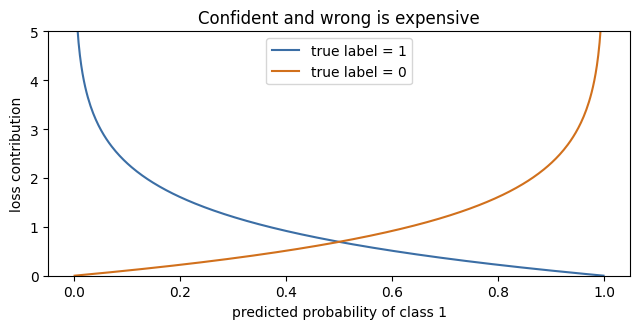

In [22]:
# The shape of the penalty
p = np.linspace(0.001, 0.999, 400)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(p, -np.log(p),     label="true label = 1", color="#3b6ea5")
ax.plot(p, -np.log(1 - p), label="true label = 0", color="#d1701c")
ax.set_xlabel("predicted probability of class 1"); ax.set_ylabel("loss contribution")
ax.set_title("Confident and wrong is expensive"); ax.legend(); ax.set_ylim(0, 5)
plt.tight_layout(); plt.show()

In [23]:
def bce(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)     # guard against log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [24]:
y

array([[1.],
       [1.],
       [0.],
       [0.]])

In [25]:
A2

array([[0.5585],
       [0.7109],
       [0.4651],
       [0.5498]])

In [26]:
loss = bce(y, A2)
print("per-example loss:", np.round(-(y * np.log(A2) + (1 - y) * np.log(1 - A2)).ravel(), 4))
print(f"mean loss: {loss:.6f}")
print(f"accuracy:  {((A2 > 0.5) == (y > 0.5)).mean():.2f}")

per-example loss: [0.5825 0.3412 0.6256 0.7981]
mean loss: 0.586856
accuracy:  0.75


The per-example losses show where the model is hurting most. Example 4 is the worst offender — the model says 0.55 for something that should be 0.

**Questions.**

1. What is the loss if the model predicts exactly the right label with total confidence on all four examples?
2. Why do we clip predictions away from 0 and 1 inside `bce`? What breaks otherwise?
3. Accuracy here is 0.75 and loss is 0.585. Suppose after training accuracy stays at 0.75 but loss drops to 0.40. Did the model improve?

## 6. Gradients as local slope

We now have one number that tells us how wrong the model is: **the loss**.

The next question is the heart of deep learning:

> **If I change one parameter by a tiny amount, does the loss go up or down, and by how much?**

That is what the **gradient** tells us.

There is nothing mysterious about it. The gradient of the loss with respect to a parameter, such as a weight \(w\), tells us the **local slope of the loss** as we change that parameter while keeping everything else fixed.

Think of the parameter as a knob.

We turn the knob slightly and ask:

> *Did the loss get better or worse? And how strongly did it change?*

The gradient gives us two important pieces of information:

* **The sign tells us the direction.**
  A positive gradient means increasing the parameter makes the loss increase, so gradient descent moves the parameter in the opposite direction. A negative gradient means increasing the parameter decreases the loss, so gradient descent moves it upward.

* **The magnitude tells us how steep the slope is.**
  A large gradient means a small change in that parameter produces a relatively large change in the loss. A gradient close to zero means the loss barely changes when we nudge that parameter.

So, in simple terms:

> **The gradient tells us which way to move a parameter and how strongly that parameter should be adjusted.**

### From Gradient to Gradient Descent

Now we can put the idea into an equation.

The basic gradient descent update is:

$$
w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial L}{\partial w}
$$

Don't let the notation make this look more complicated than it is.

* $(w)$ is the parameter we are updating.
* $(L)$ is the loss.
* $(\frac{\partial L}{\partial w})$ is the gradient: how the loss changes when we change \(w\).
* $(\eta)$ is the **learning rate**: how big a step we take.

The most important part is the **minus sign**.

We subtract the gradient because the gradient points in the direction where the loss increases. Gradient descent wants to move in the **opposite direction**, toward a lower loss.

For example, if:

$$
\frac{\partial L}{\partial w}=2
$$

the gradient is positive, so we decrease \(w\).

If:

$$
\frac{\partial L}{\partial w}=-2
$$

the gradient is negative, so subtracting it causes \(w\) to increase.

The learning rate controls **how far we move**.

A large learning rate takes bigger steps. A small learning rate takes smaller steps.

So the whole process can be reduced to one simple idea:

> **Look at the slope, move in the opposite direction, and control the size of the step with the learning rate.**

And we don't actually need calculus to understand the basic idea.

We can estimate the gradient by **brute force**.

Take a weight \(w\). Add a tiny amount $(\epsilon)$ to it. Recalculate the loss. Compare the new loss with the original loss.

If the loss changed a lot, the slope is steep. If it barely changed, the slope is shallow. Whether the loss went up or down tells us the direction of the slope.

This is called a **finite-difference estimate**.

In practice, neural networks use calculus-based methods such as **backpropagation** to calculate gradients efficiently across millions or even billions of parameters. But finite differences remain extremely useful: engineers use them to **check that their gradient calculations are correct**.

So the big picture is:

**Loss tells us how wrong we are.
The gradient tells us how changing each parameter affects that wrongness.
Gradient descent uses the gradient to decide which direction to move and the learning rate to decide how far.**

In [27]:
def forward_loss(W1, b1, W2, b2):
    """Run the full forward pass and return the loss. Used for numerical probing."""
    A1 = relu(X @ W1 + b1)
    A2 = sigmoid(A1 @ W2 + b2)
    return bce(y, A2)


base = forward_loss(W1, b1, W2, b2)
eps = 1e-5

# Probe ONE parameter: W2[0,0], the weight from hidden neuron 1 to the output
W2_up = W2.copy(); W2_up[0, 0] += eps
slope = (forward_loss(W1, b1, W2_up, b2) - base) / eps

print(f"loss now                         : {base:.6f}")
print(f"loss after nudging W2[0,0] by 1e-5: {forward_loss(W1, b1, W2_up, b2):.6f}")
print(f"estimated slope dL/dW2[0,0]      : {slope:+.6f}")
print()
direction = "DECREASE" if slope > 0 else "INCREASE"
print(f"The slope is {'positive' if slope > 0 else 'negative'}, so increasing this weight")
print(f"{'increases' if slope > 0 else 'decreases'} the loss. To reduce loss we should {direction} it.")

loss now                         : 0.586856
loss after nudging W2[0,0] by 1e-5: 0.586855
estimated slope dL/dW2[0,0]      : -0.077781

The slope is negative, so increasing this weight
decreases the loss. To reduce loss we should INCREASE it.


In [28]:
# Probe every parameter the same brute-force way
def numerical_gradients(W1, b1, W2, b2, eps=1e-5):
    grads = {}
    for name, P in [("W1", W1), ("b1", b1), ("W2", W2), ("b2", b2)]:
        g = np.zeros_like(P)
        for idx in np.ndindex(P.shape):
            up = P.copy(); up[idx] += eps
            kwargs = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
            kwargs[name] = up
            g[idx] = (forward_loss(**kwargs) - forward_loss(W1, b1, W2, b2)) / eps
        grads[name] = g
    return grads


num_grads = numerical_gradients(W1, b1, W2, b2)
for k, v in num_grads.items():
    print(f"dL/d{k}\n{v}\n")

dL/dW1
[[-0.1145  0.0465]
 [ 0.052  -0.0465]]

dL/db1
[[-0.1278 -0.0465]]

dL/dW2
[[-0.0778]
 [ 0.0988]]

dL/db2
[[0.0711]]



Our brute-force experiment has now given us a gradient for **every parameter**.

In this small network, that means nine numbers: one gradient for each parameter. Together, they tell us **how the loss responds to changing every part of the model**.

You can think of the collection of gradients as a map of the local landscape:

> **For every parameter, which direction should we move, and how strongly does it affect the loss?**

Now look at the two columns of `dL/dW1`.

The second column, which corresponds to the weights of **hidden neuron 2**, has noticeably smaller gradients than the first.

We can explain this by looking back at `A1` from Section 3.

Hidden neuron 2 was activated on only **one of the four examples**. On the other three examples, ReLU output zero. That means neuron 2 contributed nothing to those three predictions, so changing its weights cannot affect the loss for those examples.

Hidden neuron 1, on the other hand, was active on **two of the four examples**, so its weights had more opportunities to influence the predictions and, therefore, the loss.

This gives us an important idea:

> **A neuron that contributed nothing to a prediction cannot receive blame for that prediction's error.**

That is **credit assignment** beginning to appear directly in the numbers, even before we formally define the term.

**`So why not just use numerical gradients?`**

At this point, you might reasonably ask:

> **If we can calculate gradients this way, why do we need backpropagation?**

The problem is the cost.

Our numerical method works by changing **one parameter at a time**, running the entire forward pass again, and measuring how much the loss changes.

For this tiny network, nine parameters require roughly **nine additional forward passes**.

That is manageable for a toy example.

But imagine a neural network with **one billion parameters**.

Using this method would require roughly **one billion forward passes for a single training step**.

That is computationally impractical.

Backpropagation solves this problem in a fundamentally more efficient way. Instead of separately probing every parameter, it uses the **chain rule of calculus** to calculate the gradients of all the parameters together, in roughly the computational cost of **one forward pass plus one backward pass**.

That efficiency is not merely a nice optimisation.

> **Backpropagation is one of the fundamental reasons we can train modern deep neural networks at all.**

Our brute-force numerical method is therefore useful for something different: **understanding what a gradient means and verifying that our backpropagation implementation is producing the right answers.**


**Questions.**

1. Why did we choose $\epsilon = 10^{-5}$? What goes wrong if it is far larger, or far smaller?
2. Which parameter currently has the largest gradient magnitude, and what does that tell you?
3. If a gradient is exactly zero, has the parameter found its best value?

## 7. The computational graph

To get all nine gradients cheaply, we need to see the forward pass as what it really is: a **chain of simple operations**, each one recording what it did.

<div align="center">

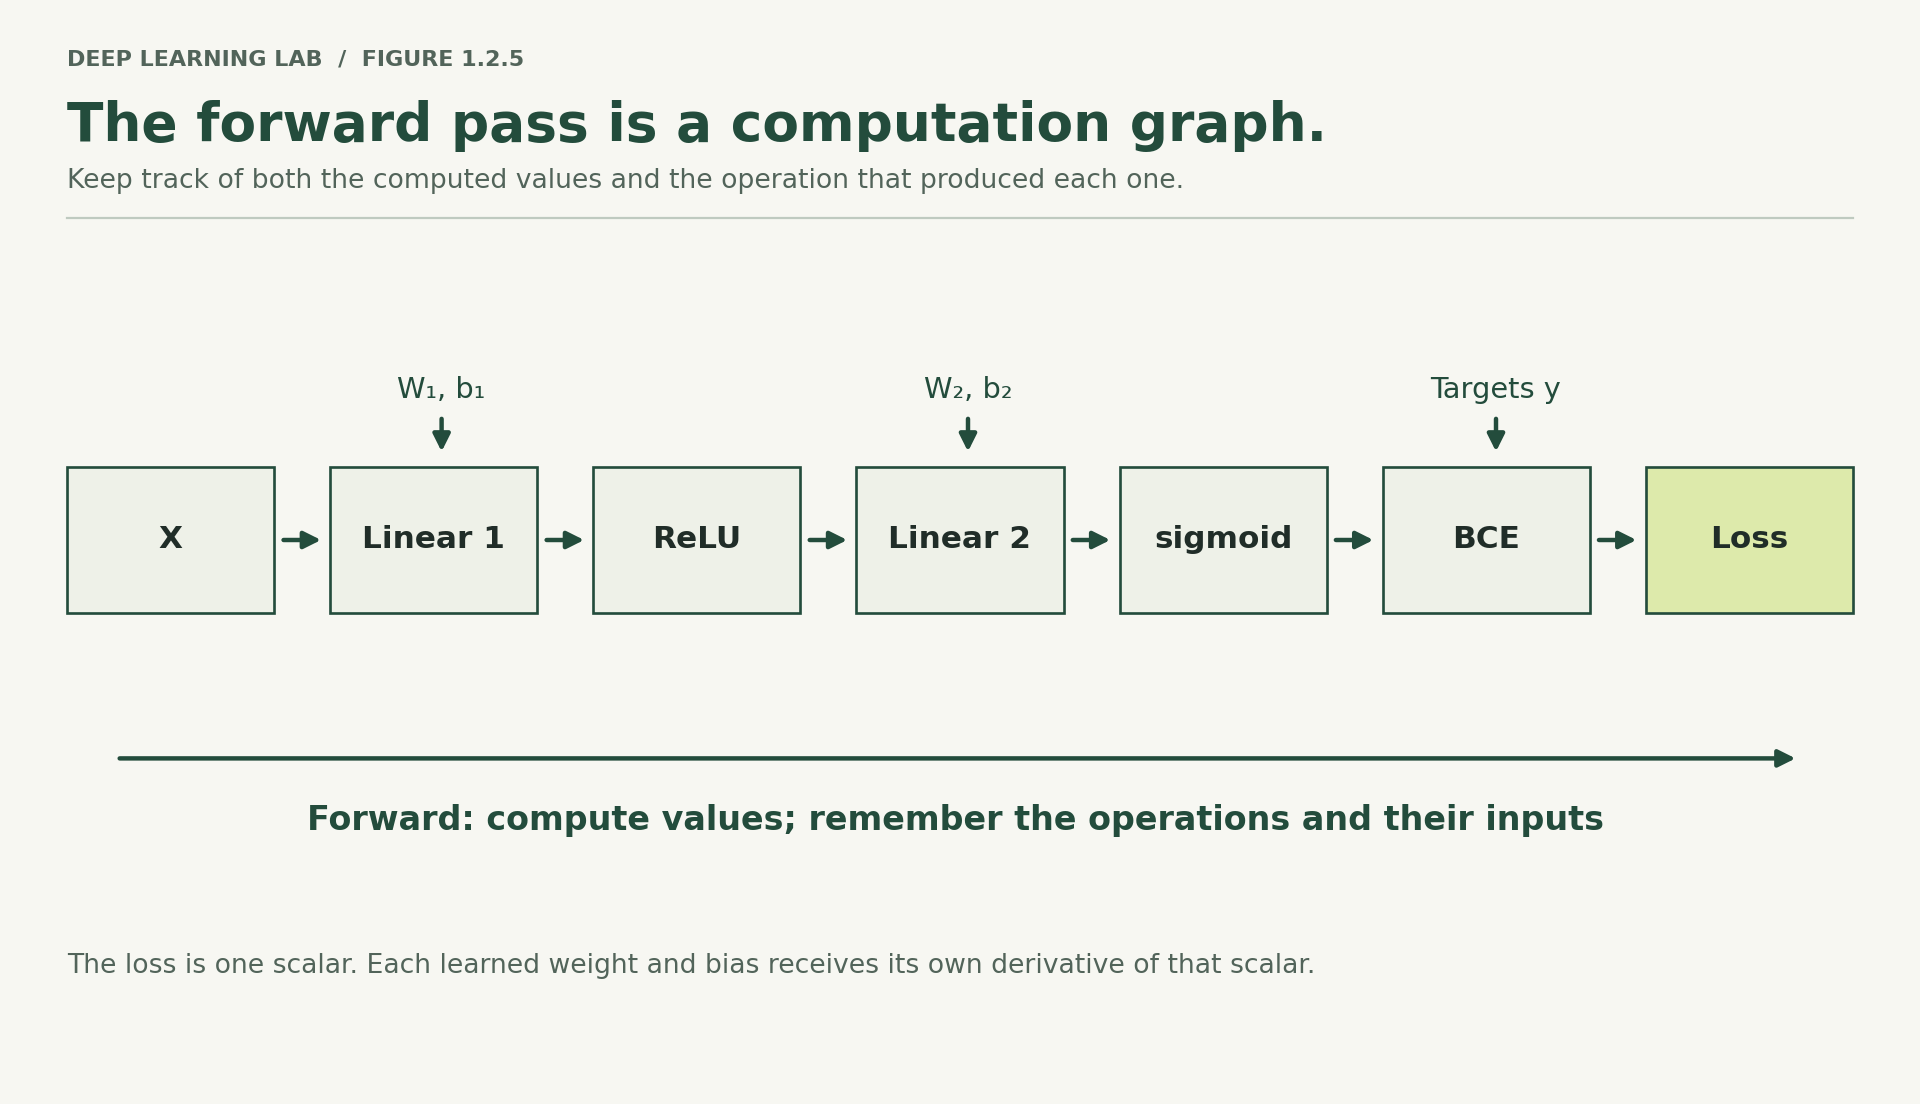

<p><b>Figure 1.2.5.</b> The same graph supports both directions. Forward computes predictions and loss; backward follows dependencies to compute gradients.</p>

</div>

Every node is one elementary operation. Each knows two things: the inputs it received, and how to convert a gradient at its output into gradients at its inputs. That is all.

The rule linking them is the **chain rule**, and its plain-language version is the only version you need today:

> If $L$ depends on $A$, and $A$ depends on $w$, then the sensitivity of $L$ to $w$ is the sensitivity of $L$ to $A$, multiplied by the sensitivity of $A$ to $w$.

Sensitivities multiply along the chain. Nothing more.

This is also why frameworks appear to "remember" your computation. When you run a forward pass in PyTorch, every operation quietly appends itself to a graph. Calling `.backward()` walks that graph in reverse, applying each node's local rule. It is bookkeeping, executed fast — and it is why a forward pass under `torch.no_grad()` uses less memory, a fact that becomes very practical on Day 4.

<div align="center">

![Inputs pass through two linear transformations separated by ReLU, then sigmoid, binary cross-entropy and scalar loss. Weights and biases enter the linear operations, targets enter the loss. A reverse arrow shows the chain rule walking from loss back toward inputs.](attachment:figure-1.2.6.png)

<p><b>Figure 1.2.6.</b> The same graph supports both directions. Forward computes predictions and loss; backward follows dependencies to compute gradients.</p>

</div>
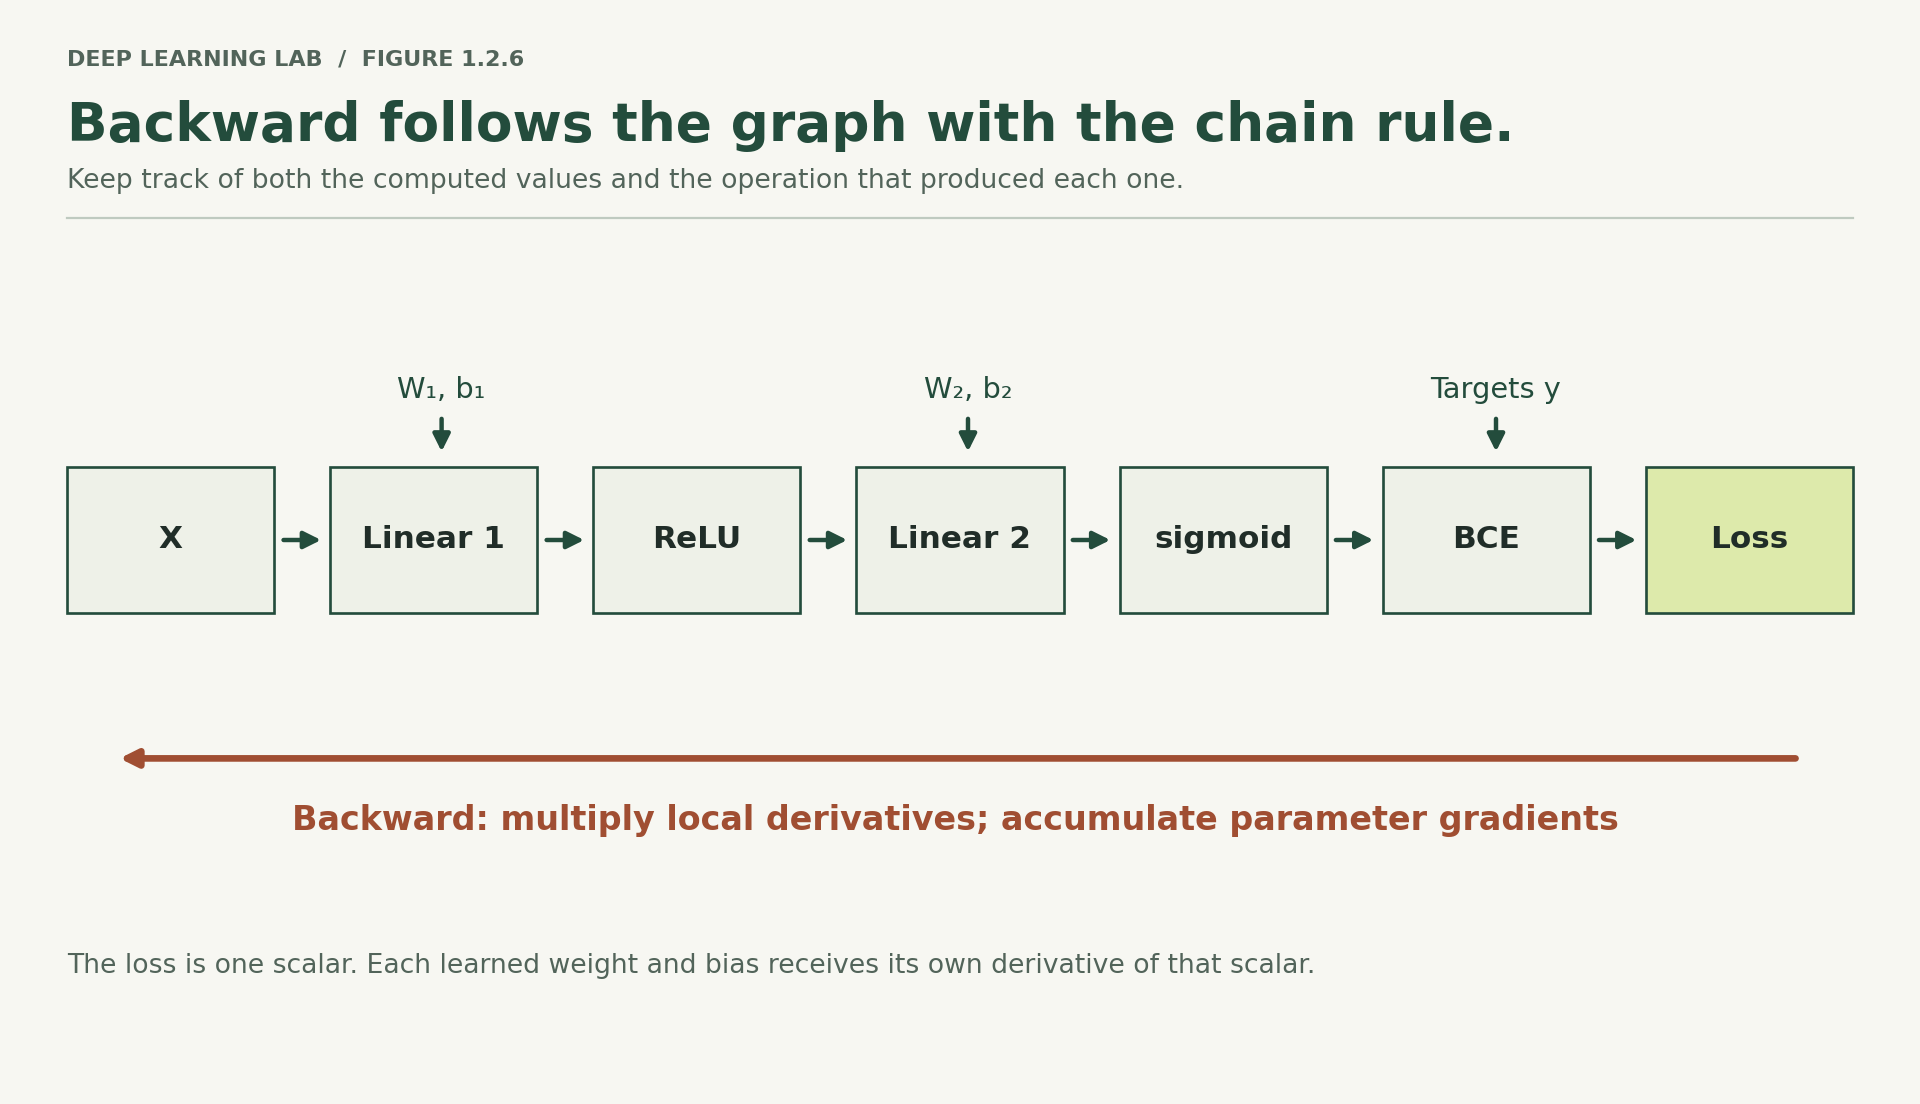

<details>
<summary>Explanation</summary>

This image illustrates the **Forward Pass** of a binary classification neural network in an automatic differentiation computational graph (like PyTorch or TensorFlow's `autograd`).

During the forward pass, the network computes output values step-by-step from left to right while simultaneously **recording local operational derivatives** (dashed boxes) so that backpropagation can instantly apply the chain rule during the backward pass.


**Step-by-Step Breakdown of Operations & Partial Derivatives**

**1. First Linear Layer (`matmul`)**

* **Operation:** Takes input $X$, multiplies by weights $W_1$, and adds bias $b_1$:

$$\text{out}_1 = X W_1 + b_1$$


* **Partial Derivatives:**
* $\frac{\partial \text{out}}{\partial \text{in}} = W_1^T$: Describes how the layer's output changes with respect to its input $X$ (needed to pass gradients backward to previous layers).
* $\frac{\partial \text{out}}{\partial W_1} = X^T$: Measures sensitivity to weight updates.
* $\frac{\partial \text{out}}{\partial b_1} = \mathbf{1}$: Measures sensitivity to bias updates.


**2. First Activation (`ReLU`)**

* **Operation:** Applies the Rectified Linear Unit activation function element-wise:

$$\text{out}_2 = \max(0, \text{in}_2)$$


* **Partial Derivatives:**
* $\frac{\partial \text{out}}{\partial \text{in}} = \begin{cases} 1 & \text{if } \text{in}_2 > 0 \\ 0 & \text{if } \text{in}_2 \le 0 \end{cases}$
* *Note:* Activation functions do not have weights or biases, so they only need the derivative with respect to their input.


**3. Second Linear Layer (`matmul`)**

* **Operation:** Takes the output from ReLU ($\text{out}_2$) and applies $W_2$ and $b_2$:

$$\text{out}_3 = \text{out}_2 W_2 + b_2$$


* **Partial Derivatives:**
* $\frac{\partial \text{out}}{\partial \text{in}} = W_2^T$
* $\frac{\partial \text{out}}{\partial W_2} = \text{out}_2^T$
* $\frac{\partial \text{out}}{\partial b_2} = \mathbf{1}$


**4. Output Activation (`sigmoid`)**

* **Operation:** Maps input values to probabilities between 0 and 1:

$$\hat{y} = \sigma(\text{in}_4) = \frac{1}{1 + e^{-\text{in}_4}}$$


* **Partial Derivatives:**
* $\frac{\partial \text{out}}{\partial \text{in}} = \sigma(\text{in}_4)(1 - \sigma(\text{in}_4)) = \hat{y}(1 - \hat{y})$


**5. Binary Cross-Entropy Loss (`BCE loss`)**

* **Operation:** Calculates scalar loss $L$ by comparing prediction $\hat{y}$ with true label $y$:

$$L = - \left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right)$$


* **Partial Derivatives:**
* $\frac{\partial L}{\partial \text{in}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$


**Why Are These Local Derivatives Recorded During Forward Pass?**

To execute backpropagation efficiently, deep learning frameworks construct a computational graph. When calling `.backward()`:

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \text{out}_4} \cdot \frac{\partial \text{out}_4}{\partial \text{out}_3} \cdot \frac{\partial \text{out}_3}{\partial \text{out}_2} \cdot \frac{\partial \text{out}_2}{\partial \text{out}_1} \cdot \frac{\partial \text{out}_1}{\partial W_1}$$

By computing and storing these individual local partial derivatives ($\frac{\partial \text{out}}{\partial \text{in}}$, $\frac{\partial \text{out}}{\partial W}$, $\frac{\partial \text{out}}{\partial b}$) during the forward pass, the system can multiply them together sequentially in reverse without recomputing function values.
</detials>

**Question.** In the diagram, which stored values must be kept in memory during the forward pass in order for the backward pass to work? This question is the entire reason training uses far more memory than inference — Day 4 returns to it.

## 8. Backpropagation as credit assignment

Here is the sentence to remember:

> **Backpropagation is credit assignment through the computational graph.**

The loss is one number produced by **all nine parameters working together**. Backpropagation works backwards from that loss, efficiently determining **how much each parameter contributed to the error**.

We’ll do this one step at a time. You only need two derivative facts, and both are worth understanding rather than simply looking up.

**Fact 1: Sigmoid + binary cross-entropy**

For a sigmoid output with binary cross-entropy loss, the gradient at the output pre-activation is remarkably simple:

$$\frac{\partial L}{\partial z_2} = \frac{\hat{y} - y}{N}$$

In plain English:

> **Prediction minus truth, averaged across the examples.**

The sigmoid derivative and the logarithm terms from cross-entropy cancel neatly. This is not an accident. The sigmoid + binary cross-entropy pairing is widely used in part because this combination gives us this elegant gradient.

**Fact 2: ReLU**

ReLU behaves like an **on/off switch** during backpropagation.

Its derivative is **1 when the input is positive** and **0 when the input is negative**.

So when we move backwards through the network, an active neuron lets the gradient pass through; an inactive neuron blocks it.

And that gives us the basic mechanism:

**Start with the loss → move backwards through each operation → pass the gradient according to each operation's derivative → eventually reach every parameter.**

Now, let’s walk backwards.


In [29]:
N = len(X)

# --- step 1: gradient at the output pre-activation Z2 ---
dZ2 = (A2 - y) / N                      # (4,1)   "prediction minus truth"

# --- step 2: parameters of layer 2 ---
dW2 = A1.T @ dZ2                        # (2,4) @ (4,1) -> (2,1)
db2 = dZ2.sum(axis=0, keepdims=True)    # (1,1)   bias sees every example equally

# --- step 3: push the gradient back to the hidden activations ---
dA1 = dZ2 @ W2.T                        # (4,1) @ (1,2) -> (4,2)

# --- step 4: back through ReLU — the on/off switch ---
dZ1 = dA1 * (Z1 > 0)                    # zero out wherever the neuron was inactive

# --- step 5: parameters of layer 1 ---
dW1 = X.T @ dZ1                         # (2,4) @ (4,2) -> (2,2)
db1 = dZ1.sum(axis=0, keepdims=True)    # (1,2)

for name, g in [("dW1", dW1), ("db1", db1), ("dW2", dW2), ("db2", db2)]:
    print(f"{name}\n{g}\n")

dW1
[[-0.1145  0.0465]
 [ 0.052  -0.0465]]

db1
[[-0.1278 -0.0465]]

dW2
[[-0.0778]
 [ 0.0988]]

db2
[[0.0711]]



In [30]:
# Do these match the brute-force gradients from Section 6?
print(f"{'parameter':<12}{'max abs difference':>22}")
print("-" * 34)
for name, analytic in [("W1", dW1), ("b1", db1), ("W2", dW2), ("b2", db2)]:
    diff = np.abs(analytic - num_grads[name]).max()
    print(f"{name:<12}{diff:>22.3e}")
print("\nAgreement to ~1e-6 is exactly what finite-difference precision allows.")
print("Anything larger would mean a bug in the backward pass.")
print("This check has a name — gradient checking — and it is how you verify")
print("hand-written backward passes in real work.")

parameter       max abs difference
----------------------------------
W1                       3.210e-07
b1                       2.769e-07
W2                       2.576e-07
b2                       1.185e-06

Agreement to ~1e-6 is exactly what finite-difference precision allows.
Anything larger would mean a bug in the backward pass.
This check has a name — gradient checking — and it is how you verify
hand-written backward passes in real work.


They agree. You now have the same nine numbers by two completely independent routes: brute-force probing, and one backward walk through the graph.

Take a moment on **step 3**, because it is the heart of the idea. `dZ2 @ W2.T` distributes the output error back to the hidden neurons *in proportion to the weights connecting them*. A hidden neuron wired to the output with a large weight receives a large share of the blame; one wired with a small weight receives little. That is credit assignment made arithmetic.

And **step 4** is where the sparsity you noticed earlier becomes formal. Multiplying by `(Z1 > 0)` cuts off every path through an inactive neuron. No activity, no responsibility, no update.

**Questions.**

1. Trace one number by hand: compute `dW2[0,0]` yourself as the dot product of column 0 of `A1` with `dZ2`. Does it match?
2. Why does `db2` sum over examples while `dW2` involves a matrix multiply?
3. Imagine a 50-layer network where each layer's local gradient is around 0.5. What has happened to the gradient by the time it reaches layer 1? (This is the vanishing gradient problem, and it explains architectural choices you will meet on Day 6.)

## 9. One parameter update, by hand

We know, for each of the nine parameters, whether increasing it raises or lowers the loss. So take a small step in the direction that lowers it:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

The minus sign is the whole algorithm: gradients point *uphill*, and we want to go *down*. The symbol $\eta$ is the **learning rate** — how big a step to take.

Before running the cell, predict the outcome. The current loss is 0.5845. After one step with $\eta = 0.5$, will the loss go up or down?

In [31]:
W1

array([[ 0.5, -0.2],
       [ 0.3,  0.8]])

In [32]:
dW1

array([[-0.1145,  0.0465],
       [ 0.052 , -0.0465]])

In [33]:
b1

array([[ 0.1 , -0.15]])

In [34]:
db1

array([[-0.1278, -0.0465]])

In [35]:
LR = 0.5

In [36]:
W1_new = W1 - LR * dW1
b1_new = b1 - LR * db1
W2_new = W2 - LR * dW2
b2_new = b2 - LR * db2

In [37]:
W1_new

array([[ 0.5573, -0.2233],
       [ 0.274 ,  0.8233]])

In [38]:
b1_new

array([[ 0.1639, -0.1267]])

In [39]:
loss_before = forward_loss(W1, b1, W2, b2)

In [40]:
loss_after  = forward_loss(W1_new, b1_new, W2_new, b2_new)

In [41]:
print("W2 before:", W2.ravel(), " ->  after:", W2_new.ravel())
print("b2 before:", b2.ravel(), " ->  after:", b2_new.ravel())
print()
print(f"loss before update: {loss_before:.6f}")
print(f"loss after  update: {loss_after:.6f}")
print(f"improvement:        {loss_before - loss_after:+.6f}")

W2 before: [ 0.7 -0.4]  ->  after: [ 0.7389 -0.4494]
b2 before: [0.2]  ->  after: [0.1645]

loss before update: 0.586856
loss after  update: 0.559278
improvement:        +0.027577


It went down. Small, unglamorous, and entirely real.

That is one training step. Everything else in deep learning is this operation repeated — with more parameters, more data, and cleverer rules for choosing $\eta$, but the same three moves: forward, backward, update.

**Questions.**

1. Some parameters barely moved. Which ones, and why?
2. Would a step of $\eta = 5.0$ reduce the loss ten times as much? Change `LR` and find out.
3. The gradient describes the slope *at the current point only*. Why does that make large steps risky?

## 10. Looping it: watching loss fall

One step helped a little. Now do it repeatedly. This cell is a complete training loop written in NumPy — and structurally it is the same loop you will write in PyTorch in Note 1.3, and the same loop that trains models with billions of parameters.

In [42]:
X.shape

(4, 2)

epoch    0   loss 0.6638   accuracy 0.50
epoch   50   loss 0.4811   accuracy 0.75
epoch  100   loss 0.4787   accuracy 0.75
epoch  150   loss 0.1051   accuracy 1.00
epoch  200   loss 0.0445   accuracy 1.00
epoch  250   loss 0.0268   accuracy 1.00

final loss: 0.0189


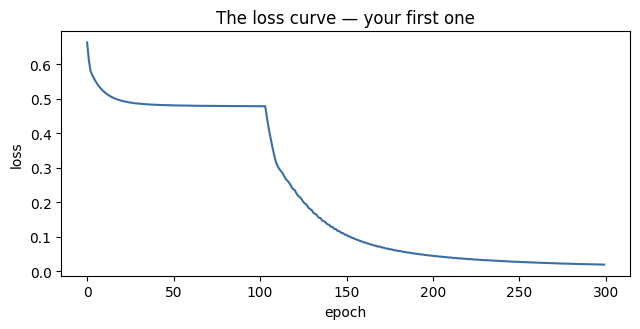

In [54]:
def train(X, y, lr=0.5, epochs=300, seed=SEED, verbose=True):
    """Full training loop in plain NumPy: forward, backward, update, repeat."""
    rng = np.random.default_rng(seed)
    # Small random initialisation — Day 3 explains why the scale matters
    W1 = rng.normal(0, 0.5, (2, 2)); b1 = np.zeros((1, 2))
    W2 = rng.normal(0, 0.5, (2, 1)); b2 = np.zeros((1, 1))
    history = []

    for epoch in range(epochs):
        # ---------- forward ----------
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)
        loss = bce(y, A2)
        history.append(loss)

        # ---------- backward ----------
        N = len(X)
        dZ2 = (A2 - y) / N
        dW2 = A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dZ1 = (dZ2 @ W2.T) * (Z1 > 0)
        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)

        # ---------- update ----------
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2

        if verbose and epoch % 50 == 0:
            acc = ((A2 > 0.5) == (y > 0.5)).mean()
            print(f"epoch {epoch:>4}   loss {loss:.4f}   accuracy {acc:.2f}")

    return history, (W1, b1, W2, b2)


history, params = train(X, y)
print(f"\nfinal loss: {history[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(history, color="#3b6ea5")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title("The loss curve — your first one")
plt.tight_layout(); plt.show()

That curve is the single most-read diagnostic in deep learning, and you will spend most of Day 3 interpreting its variants. For now, note its characteristic shape: steep at first, where gradients are large and there is plenty to fix, then flattening as the model approaches a solution and the slopes shrink.

One caveat, stated now so it does not become a bad habit. This model is fitting four examples and we are measuring loss on the same four. That is training loss, not validation loss, and a model that memorises four points has demonstrated nothing about generalisation. With real data this would be malpractice. Note 1.3 introduces the split properly.

**Questions.**

1. Run `train(X, y, lr=0.01)`. What does the curve look like, and would you know the model was fine if you only saw 300 epochs?
2. Run `train(X, y, lr=5.0)`. What happens, and can you explain it in terms of Section 9's warning?
3. Change `seed` and re-run a few times. Why does the final loss differ, and what does that imply for reporting results?

## 11. The learning rate

The learning rate is the hyperparameter you will get wrong most often, so it deserves its own picture. Run all three regimes side by side.

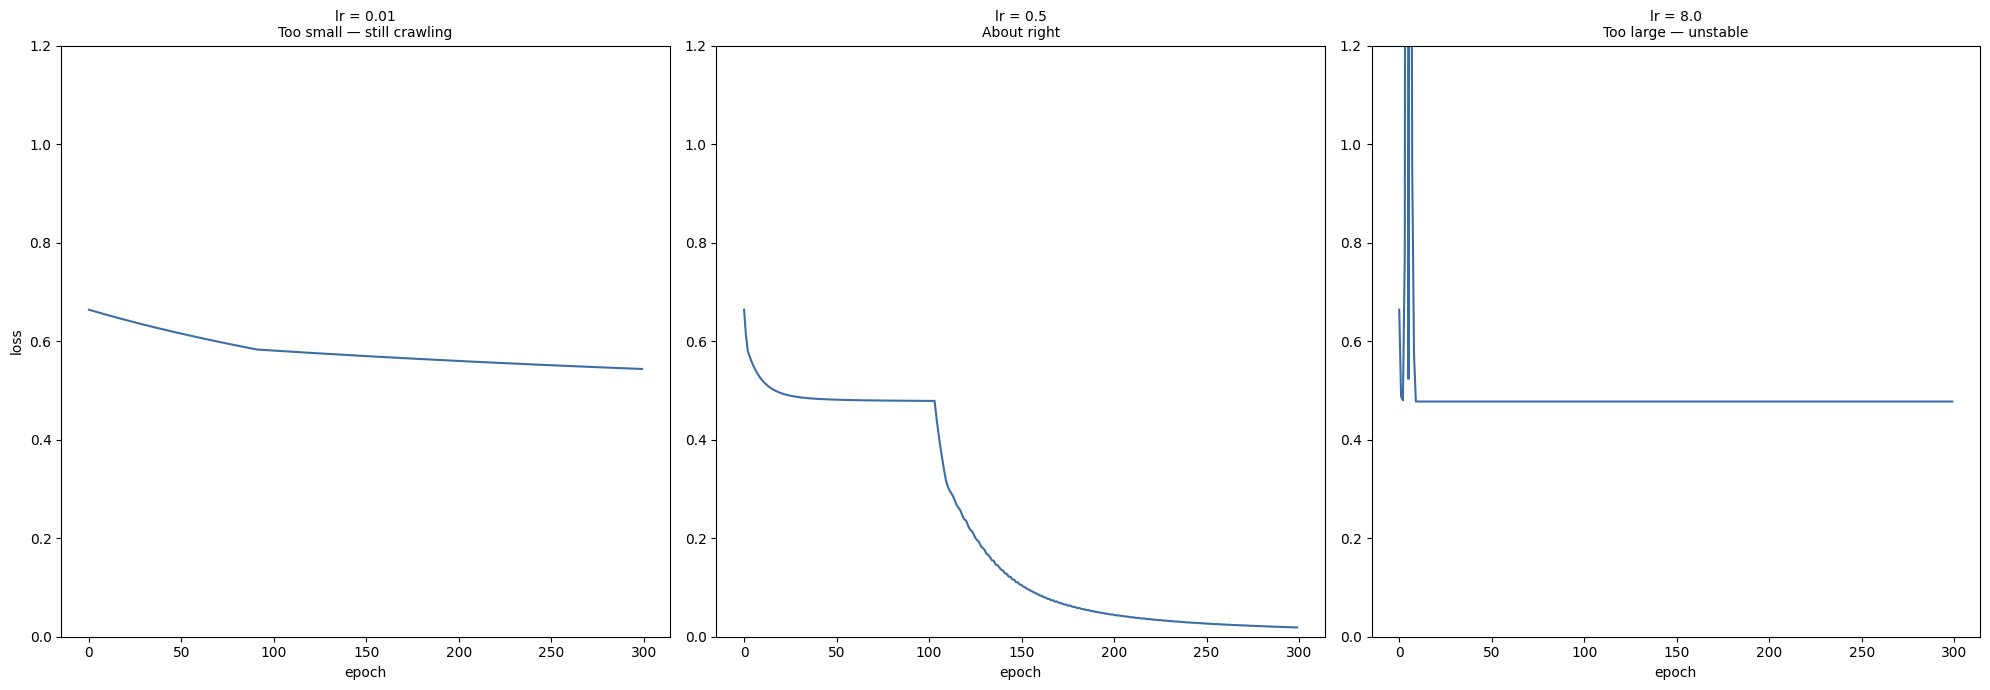

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
settings = [(0.01, "Too small — still crawling"),
            (0.50, "About right"),
            (8.00, "Too large — unstable")]

for ax, (lr, title) in zip(axes, settings):
    h, _ = train(X, y, lr=lr, epochs=300, verbose=False)
    ax.plot(h, color="#3b6ea5")
    ax.set_title(f"lr = {lr}\n{title}", fontsize=10)
    ax.set_xlabel("epoch"); ax.set_ylim(0, 1.2)
axes[0].set_ylabel("loss")
plt.tight_layout(); plt.show()

Three failure modes, three signatures you should be able to recognise on sight:

- **Too small.** The loss falls, but so slowly that you cannot tell whether the model is learning or stuck. This wastes far more engineering time than it should, because nothing looks broken.
- **About right.** Rapid early progress, then a smooth flattening.
- **Too large.** The step overshoots the valley and lands further up the opposite side. The loss oscillates, plateaus at a bad value, or diverges outright.

<div align="center">

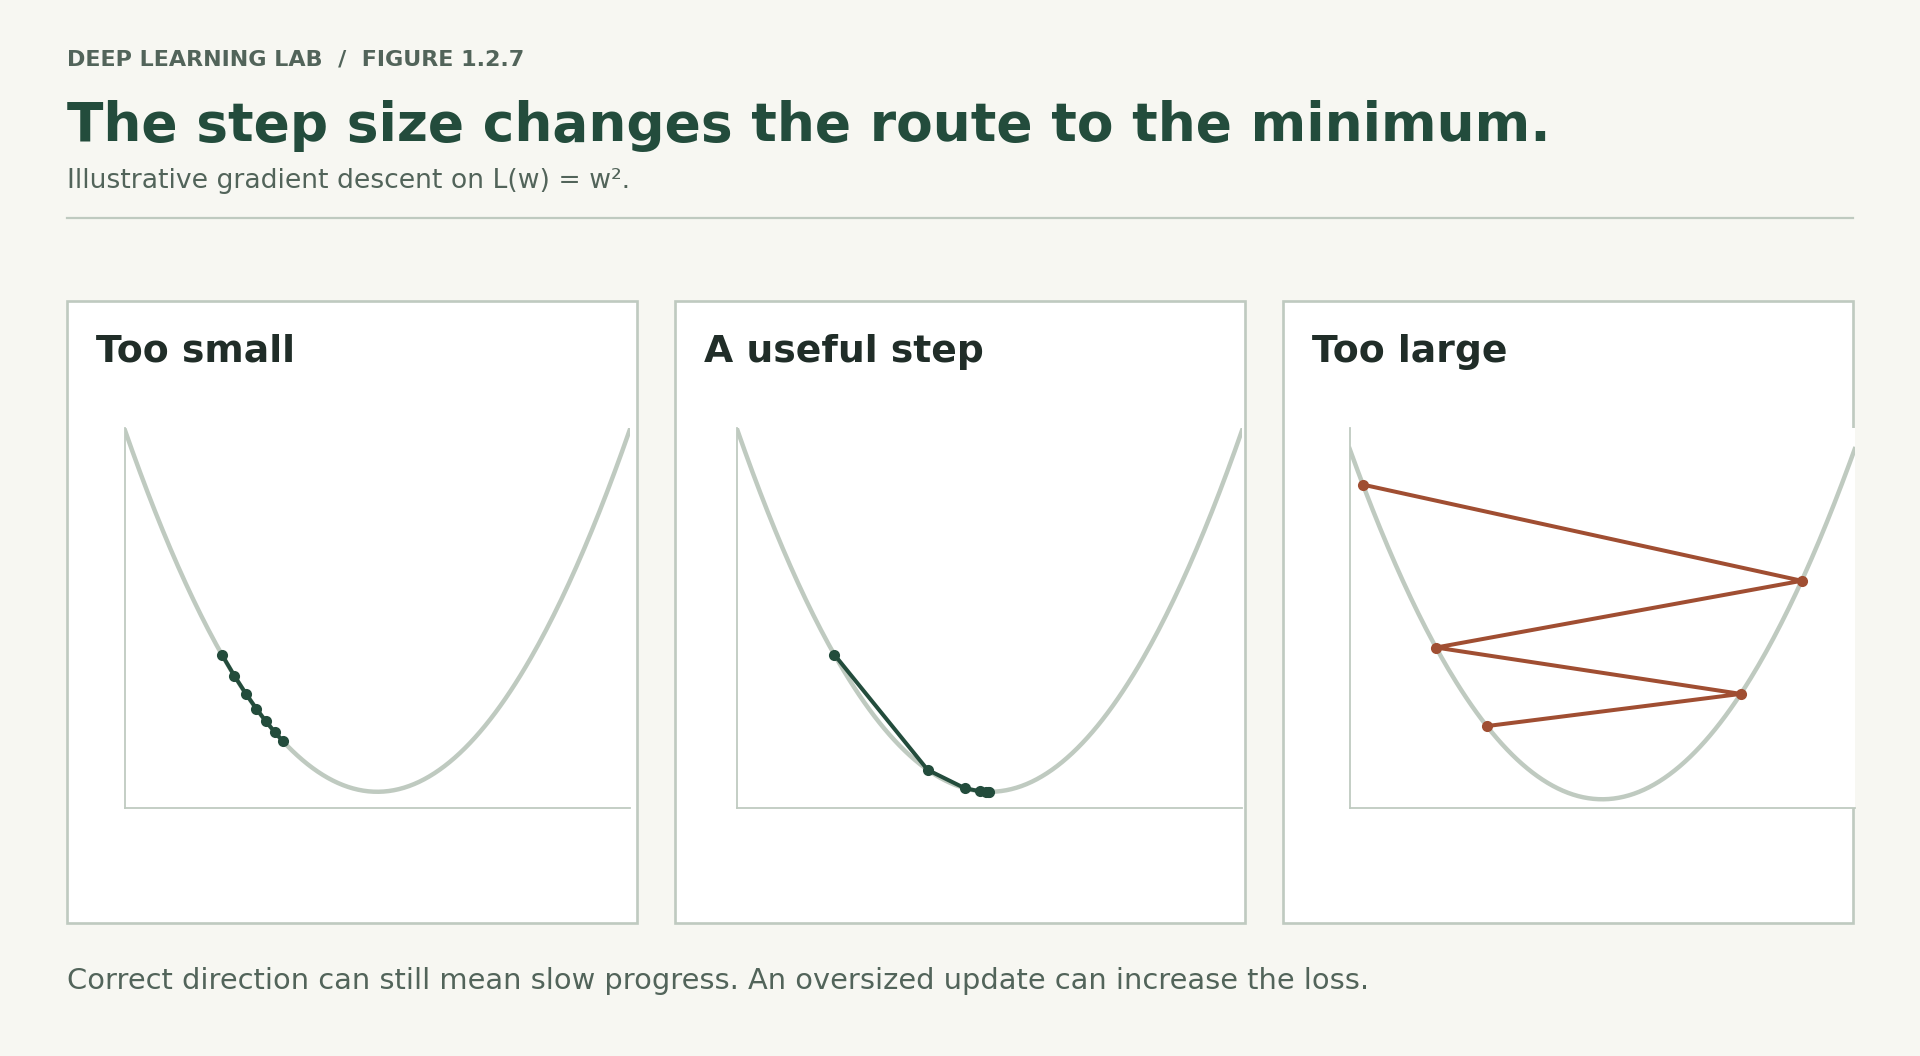

<p><b>Figure 1.2.7.</b> Calculated descent paths on a simple quadratic: η=0.04, 0.3 and 1.1. This is a learning-rate illustration, not the network’s measured training run.</p>

</div>

In 2026 nobody picks a single fixed learning rate and leaves it there. Optimisers such as Adam adapt the effective step size per parameter, and schedulers vary it over training — typically warming up and then decaying. You will use both on Day 3. But every one of those methods is a refinement of the trade-off in this picture, and understanding the picture is what lets you diagnose them when they misbehave.

**Questions.**

1. Given only a loss curve, how would you distinguish "learning rate too small" from "model lacks capacity"?
2. Why might a large learning rate be *desirable* early in training and harmful later?
3. `lr=8.0` did not produce `NaN` here. What kind of change would make it do so?

## 12. The bridge: PyTorch reproduces your arithmetic exactly

Everything above was NumPy that you could audit line by line. Now we hand the identical problem to PyTorch — same data, same initial weights, same loss — and compare its gradients with the ones you derived.

In [ ]:
pip install torch

In [57]:
import torch
import torch.nn.functional as F

# Same numbers, now as tensors. requires_grad=True means "track operations on this".
tX = torch.tensor(X)
ty = torch.tensor(y)
tW1 = torch.tensor(W1, requires_grad=True)
tb1 = torch.tensor(b1, requires_grad=True)
tW2 = torch.tensor(W2, requires_grad=True)
tb2 = torch.tensor(b2, requires_grad=True)

# Forward pass — PyTorch silently records the computational graph from Section 7
tZ1 = tX @ tW1 + tb1
tA1 = torch.relu(tZ1)
tZ2 = tA1 @ tW2 + tb2

# Combines sigmoid + BCE in one numerically stable step (the cancellation from Fact 1)
tloss = F.binary_cross_entropy_with_logits(tZ2, ty)

print(f"PyTorch loss: {tloss.item():.6f}")
print(f"Your loss:    {forward_loss(W1, b1, W2, b2):.6f}")

# One line replaces all of Section 8
tloss.backward()

PyTorch loss: 0.586856
Your loss:    0.586856


In [58]:
print(f"{'parameter':<12}{'your gradient':>34}{'max diff vs PyTorch':>24}")
print("-" * 70)
for name, mine, theirs in [("W1", dW1, tW1.grad), ("b1", db1, tb1.grad),
                           ("W2", dW2, tW2.grad), ("b2", db2, tb2.grad)]:
    diff = np.abs(mine - theirs.numpy()).max()
    print(f"{name:<12}{str(np.round(mine.ravel(), 5)):>34}{diff:>24.2e}")

print("\nIdentical. Not approximately — identical.")

parameter                        your gradient     max diff vs PyTorch
----------------------------------------------------------------------
W1           [-0.1145  0.0465  0.052  -0.0465]                0.00e+00
b1                           [-0.1278 -0.0465]                0.00e+00
W2                           [-0.0778  0.0988]                0.00e+00
b2                                    [0.0711]                0.00e+00

Identical. Not approximately — identical.


Zero difference, to the last bit.

Sit with that for a moment, because it is the point of this entire note. `loss.backward()` is not a magic box. It is the five-step walk you performed in Section 8, executed by code that knows the local derivative rule for every operation. When you write it in Note 1.3, you will know precisely which arithmetic you delegated and why it is safe to do so.

This is also what makes you able to *debug* training. When a loss becomes `NaN` on Day 3, when gradients vanish in a deep network on Day 6, when a fine-tuning run refuses to move on Day 8 — the person who has traced the mechanism once knows where to look. The person who has only ever called `.backward()` is guessing.

**Questions.**

1. `binary_cross_entropy_with_logits` takes `tZ2` — the raw logit — rather than a probability. Why is that more numerically stable than applying sigmoid first?
2. What do you expect `tW1.grad` to contain if you call `tloss.backward()` a second time without clearing it? (Note 1.3 explains why `optimizer.zero_grad()` exists.)
3. We never wrote a backward pass for `torch.relu`. Who did, and where does it live?

## 13. Conclusion

You can now answer the day's competency question in full, and every clause is something you computed yourself.

**What happens between giving data to a neural network and the model improving?**

The data flows forward through alternating linear transformations and non-linear activations, each layer producing a new description of the input, until a final layer emits a prediction. That prediction is compared with the truth through a loss function chosen to be differentiable, yielding one number that measures wrongness. The chain of operations that produced that number is then walked in reverse, and at each step the chain rule converts the gradient at the output into gradients at the inputs — apportioning responsibility for the error across every parameter. Finally each parameter takes a small step against its gradient, scaled by the learning rate. Repeat.

Three things are worth carrying forward:

- **Non-linearity is what makes depth mean anything.** Without it, fifty layers collapse into one.
- **Backpropagation is credit assignment, and it is cheap.** One backward pass gets every gradient, where brute force would need one forward pass per parameter.
- **The learning rate governs whether any of this works.** Same gradients, same data — three completely different outcomes.

**Check yourself.** Without looking back:

- Why can we not optimise accuracy directly?
- What does `dZ1 = dA1 * (Z1 > 0)` accomplish, in words?
- Why did hidden neuron 2 receive zero gradient in Section 6?
- Name the three moves of a training step in order.

## Transition to Note 1.3

You have done autograd's job by hand, and checked its arithmetic against your own. Now we hand it back to the library — and this time you will know exactly what you delegated.

Note 1.3 rebuilds all of this in PyTorch. You will meet tensors properly, including the device handling that decides whether your code runs on CPU, on Apple Silicon through MPS, or on a CUDA GPU. You will define the same network twice: once with raw tensors so the correspondence to this note is exact, then again as an `nn.Module`, which is how it is actually written in practice. You will write the canonical training loop and justify every line of it.

Then you will point it at the spirals from Note 1.1 and watch the decision boundary form.

And at the end, we break it deliberately — three small changes, each of which silently stops the model learning. Diagnosing them is the real test of whether this note landed.

**Next:** `Note_1_3_Your_First_PyTorch_Network.ipynb`